In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data = pd.read_csv("../data/raw_data.csv")
raw_data.shape

(180812, 24)

In [3]:
raw_data.columns

Index(['bag', 'timestamp_ns', 'airspeed_cmd', 'airspeed_meas',
       'airspeed_error', 'roll_cmd', 'roll_meas', 'roll_error', 'pitch_cmd',
       'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error',
       'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z', 'engine_fault',
       'aileron_fault', 'elevator_fault', 'rudder_fault'],
      dtype='object')

In [4]:
raw_data.head(3)

,bag,timestamp_ns,airspeed_cmd,airspeed_meas,airspeed_error,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,...,vel_x,vel_y,vel_z,imu_x,imu_y,imu_z,engine_fault,aileron_fault,elevator_fault,rudder_fault
0,carbonZ_2018-07-18-12-10-11.bag,1531930511391720552,15.0,0.0,15.0,0.10,2.954323,-2.854323,-2.55,8.487809,...,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0
1,carbonZ_2018-07-18-12-10-11.bag,1531930511452938696,15.0,0.0,15.0,30.34,2.954323,27.385678,-1.31,8.487809,...,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0
2,carbonZ_2018-07-18-12-10-11.bag,1531930511484229416,15.0,0.0,15.0,30.32,2.954323,27.365677,-1.31,8.487809,...,-19.941626,-0.312905,4.295179,-0.0748,-0.023208,-0.996428,0,0,0,0


# Check Imbalance

In [5]:
raw_data[["engine_fault", "aileron_fault", "elevator_fault", "rudder_fault"]].sum()

engine_fault      18270
aileron_fault     11856
elevator_fault      453
rudder_fault       2693
dtype: int64

# Correlation with Engine Fault

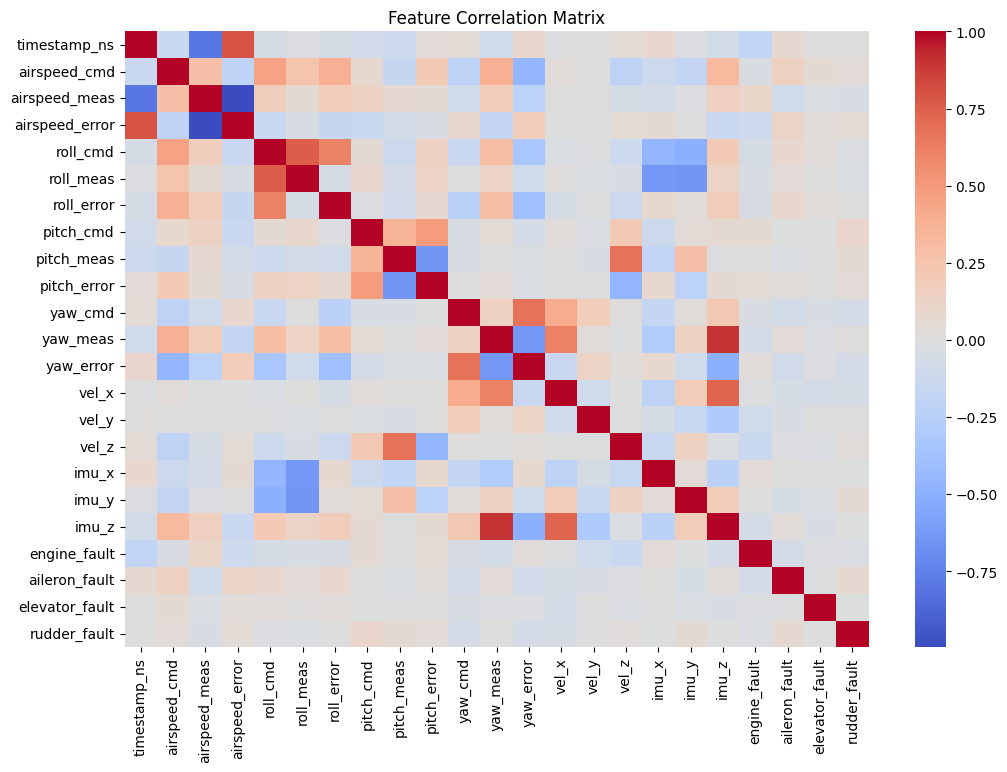

In [ ]:
corr = raw_data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [4]:
raw_data.nunique()

bag                   36
timestamp_ns      180812
airspeed_cmd           3
airspeed_meas      23256
airspeed_error     23256
roll_cmd            8691
roll_meas          24452
roll_error         87118
pitch_cmd           4156
pitch_meas         24452
pitch_error        88412
yaw_cmd              360
yaw_meas           24382
yaw_error          43289
vel_x              37426
vel_y              37430
vel_z              37433
imu_x              24465
imu_y              24465
imu_z              24465
engine_fault           2
aileron_fault          4
elevator_fault         2
rudder_fault           4
dtype: int64

In [9]:
print("--- Unique values per flight file ---")
print(raw_data.groupby("bag").nunique())



--- Unique values per flight file ---
                                 timestamp_ns  airspeed_cmd  airspeed_meas  \
bag                                                                          
carbonZ_2018-07-18-12-10-11.bag          4306             3              1   
carbonZ_2018-07-18-15-53-31.bag          7760             3           4145   
carbonZ_2018-07-18-16-22-01.bag          2474             3           1315   
carbonZ_2018-07-18-16-37-39.bag          4029             3           2133   
carbonZ_2018-07-30-16-28-00.bag          2894             3           1531   
carbonZ_2018-07-30-16-29-45.bag          2798             3           1500   
carbonZ_2018-07-30-16-39-00.bag         11076             3           5926   
carbonZ_2018-07-30-17-02-48.bag           977             3            525   
carbonZ_2018-07-30-17-10-45.bag          2771             3           1480   
carbonZ_2018-07-30-17-20-01.bag          2878             3           1533   
carbonZ_2018-07-30-17-36-3

In [10]:
# Print out the actual raw values of the first 10 rows of a single flight
print("\n--- Actual Raw Values Example ---")
print(raw_data.dropna().head(10))


--- Actual Raw Values Example ---
                               bag         timestamp_ns  airspeed_cmd  \
0  carbonZ_2018-07-18-12-10-11.bag  1531930511391720552          15.0   
1  carbonZ_2018-07-18-12-10-11.bag  1531930511452938696          15.0   
2  carbonZ_2018-07-18-12-10-11.bag  1531930511484229416          15.0   
3  carbonZ_2018-07-18-12-10-11.bag  1531930511543160328          15.0   
4  carbonZ_2018-07-18-12-10-11.bag  1531930511568218792          15.0   
5  carbonZ_2018-07-18-12-10-11.bag  1531930511641798152          15.0   
6  carbonZ_2018-07-18-12-10-11.bag  1531930511692711368          15.0   
7  carbonZ_2018-07-18-12-10-11.bag  1531930511734307336          15.0   
8  carbonZ_2018-07-18-12-10-11.bag  1531930511785614984          15.0   
9  carbonZ_2018-07-18-12-10-11.bag  1531930511834797992          15.0   

   airspeed_meas  airspeed_error   roll_cmd  roll_meas  roll_error  pitch_cmd  \
0            0.0            15.0   0.100000   2.954323   -2.854323  -2.550000   

#Check missing values

In [5]:
# Identify missing rows
print("\n=== MISSING ROW COUNTS PER FEATURE ===")
print(raw_data.isnull().sum()[raw_data.isnull().sum() > 0])



=== MISSING ROW COUNTS PER FEATURE ===
pitch_cmd        31
pitch_meas       31
pitch_error      31
yaw_cmd          29
yaw_meas         29
yaw_error        29
vel_x          8332
vel_y          8332
vel_z          8332
dtype: int64


In [12]:
raw_data.info()
print("-----------Describe-------")
raw_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180812 entries, 0 to 180811
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   bag             180812 non-null  object 
 1   timestamp_ns    180812 non-null  int64  
 2   airspeed_cmd    180812 non-null  float64
 3   airspeed_meas   180812 non-null  float64
 4   airspeed_error  180812 non-null  float64
 5   roll_cmd        180812 non-null  float64
 6   roll_meas       180812 non-null  float64
 7   roll_error      180812 non-null  float64
 8   pitch_cmd       180781 non-null  float64
 9   pitch_meas      180781 non-null  float64
 10  pitch_error     180781 non-null  float64
 11  yaw_cmd         180783 non-null  float64
 12  yaw_meas        180783 non-null  float64
 13  yaw_error       180783 non-null  float64
 14  vel_x           172480 non-null  float64
 15  vel_y           172480 non-null  float64
 16  vel_z           172480 non-null  float64
 17  imu_x     

,timestamp_ns,airspeed_cmd,airspeed_meas,airspeed_error,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,pitch_error,...,vel_x,vel_y,vel_z,imu_x,imu_y,imu_z,engine_fault,aileron_fault,elevator_fault,rudder_fault
count,1.808120e+05,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180781.000000,180781.000000,180781.000000,...,172480.000000,172480.000000,172480.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000
mean,1.536186e+18,15.518384,3.598151,11.920233,0.108577,5.609018,-5.500441,-0.618828,0.529254,-1.148082,...,-0.918885,0.422692,-0.099759,-0.023541,-0.022540,-0.643497,0.101044,0.065571,0.002505,0.014894
std,2.552247e+15,0.499121,6.706927,6.587384,22.130786,17.678768,14.415406,5.300194,6.004932,6.449612,...,11.750616,9.250473,1.521134,0.113350,0.117660,0.466526,0.301388,0.355466,0.049991,0.191646
min,1.531931e+18,15.000000,0.000000,-11.334381,-45.000000,-66.452385,-106.205280,-24.990000,-56.880775,-93.049374,...,-25.418932,-28.912567,-12.429974,-0.644147,-0.500723,-0.999938,0.000000,0.000000,0.000000,0.000000
25%,1.532987e+18,15.000000,0.000000,15.000000,-21.502500,-1.070823,-17.283209,-2.620000,-1.096522,-3.104394,...,-11.667476,-1.701345,-0.475467,-0.039049,-0.046189,-0.978148,0.000000,0.000000,0.000000,0.000000
50%,1.536692e+18,15.990000,0.000000,15.000000,-0.100000,1.802363,-2.406277,0.000000,0.545453,-0.599695,...,0.096398,-0.014826,-0.001372,-0.008594,-0.004945,-0.867799,0.000000,0.000000,0.000000,0.000000
75%,1.538765e+18,16.000000,0.000000,16.000000,9.700000,9.861669,2.745284,1.030000,2.054404,1.072685,...,3.118262,3.166560,0.299015,0.007668,0.007748,-0.503521,0.000000,0.000000,0.000000,0.000000
max,1.539876e+18,16.000000,26.484240,16.000000,44.989998,71.281387,98.288647,20.000000,72.936531,59.410775,...,31.480824,27.429300,14.150154,0.520106,0.465286,0.706492,1.000000,3.000000,1.000000,3.000000


In [13]:
raw_data['airspeed_meas'].nunique()


23256

In [14]:
print("=== AIRSPEED TELEMETRY HEALTH REPORT ===")
# Find out how many flights actually recorded moving data
flight_stats = raw_data.groupby("bag")["airspeed_meas"].max()

active_flights = flight_stats[flight_stats > 1.0]
dead_flights = flight_stats[flight_stats <= 1.0]

print(f"Total flights with real, moving airspeed data: {len(active_flights)}")
print(f"Total flights where airspeed stays locked near zero: {len(dead_flights)}")

if len(dead_flights) > 0:
    print("\nSample of dead flight files:")
    print(dead_flights.head())

=== AIRSPEED TELEMETRY HEALTH REPORT ===
Total flights with real, moving airspeed data: 11
Total flights where airspeed stays locked near zero: 25

Sample of dead flight files:
bag
carbonZ_2018-07-18-12-10-11.bag    0.0
carbonZ_2018-09-11-11-56-30.bag    0.0
carbonZ_2018-09-11-13-57-47.bag    0.0
carbonZ_2018-09-11-14-16-55.bag    0.0
carbonZ_2018-09-11-14-22-07.bag    0.0
Name: airspeed_meas, dtype: float64


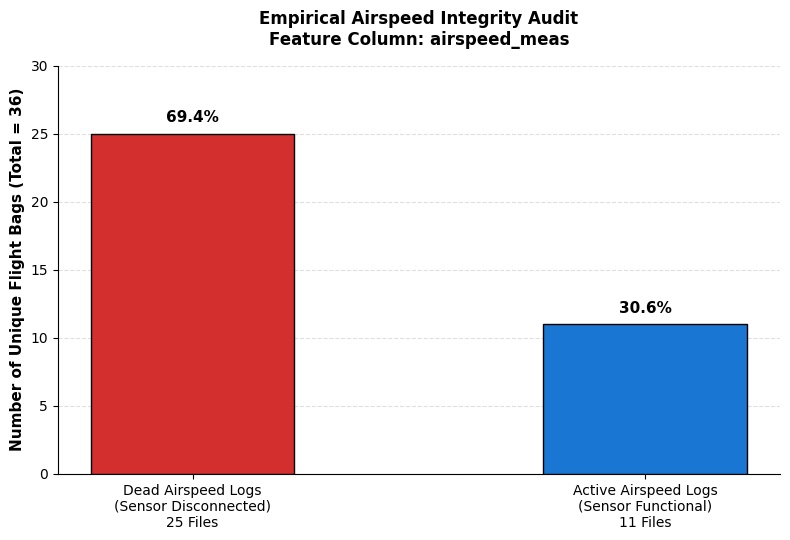

In [15]:
# Set up a professional academic styling canvas
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Initialize a single focused figure layout
fig, ax = plt.subplots(figsize=(8, 5.5))

# -----------------------------------------------------------------
# SENSO AUDIT (25 vs 11 Flights)
# -----------------------------------------------------------------
categories = [
    'Dead Airspeed Logs\n(Sensor Disconnected)\n25 Files', 
    'Active Airspeed Logs\n(Sensor Functional)\n11 Files'
]
counts = [25, 11]
percentages = [(25/36)*100, (11/36)*100]
colors = ['#d32f2f', '#1976d2'] # Academic Crimson vs Navy Blue

# Render the bar chart
bars = ax.bar(categories, counts, color=colors, edgecolor='black', width=0.45, zorder=3)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# Add exact math annotations over the bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax.annotate(f'{pct:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Academic styling, labeling, and boundaries
ax.set_ylabel('Number of Unique Flight Bags (Total = 36)', fontsize=11, fontweight='bold')
ax.set_title('Empirical Airspeed Integrity Audit\nFeature Column: airspeed_meas', fontsize=12, fontweight='bold', pad=15)
ax.set_ylim(0, 30)

# Remove the messy top and right border lines for an elegant look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# # 1. Drop all dead hardware features that contain no real values
# dead_cols = [
# #     'airspeed_cmd', 'airspeed_meas', 'airspeed_error'
# ]
# raw_data.drop(columns=dead_cols, errors='ignore', inplace=True)

# # 2. Handle the missing values (NaNs) found in the velocity channels
# # This fills the 8,332 missing velocity rows using the closest available temporal readings
# raw_data.ffill(inplace=True)
# raw_data.bfill(inplace=True)

# # 3. Engineer the True Ground Speed Feature using the active velocity vectors
# raw_data['ground_speed'] = np.sqrt(raw_data['vel_x']**2 + raw_data['vel_y']**2 + raw_data['vel_z']**2)

# # 4. Save your final cleaned, analysis-ready dataset
# raw_data.to_csv("uav_fault_dataset_cleaned.csv", index=False)

In [17]:
df = pd.read_csv("../data/uav_fault_dataset.csv")

print("\n=== CLEANED DATASET SUMMARY ===")
print(f"New CSV shape: {df.shape}")
print(f"Available Columns: {list(df.columns)}")
print("\nGround Speed Statistics:")
print(df['ground_speed'].describe())




=== CLEANED DATASET SUMMARY ===
New CSV shape: (180812, 22)
Available Columns: ['bag', 'timestamp_ns', 'roll_cmd', 'roll_meas', 'roll_error', 'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error', 'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z', 'engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault', 'ground_speed']

Ground Speed Statistics:
count    180812.000000
mean         12.630826
std           8.417556
min           0.008323
25%           0.277099
50%          16.109246
75%          18.592713
max          31.503337
Name: ground_speed, dtype: float64


In [18]:
df.describe()

,timestamp_ns,roll_cmd,roll_meas,roll_error,pitch_cmd,pitch_meas,pitch_error,yaw_cmd,yaw_meas,yaw_error,...,vel_y,vel_z,imu_x,imu_y,imu_z,engine_fault,aileron_fault,elevator_fault,rudder_fault,ground_speed
count,1.808120e+05,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,...,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000,180812.000000
mean,1.536186e+18,0.108577,5.609018,-5.500441,-0.617969,0.529203,-1.147173,10.950053,-47.446800,58.396853,...,0.021302,-0.143704,-0.023541,-0.022540,-0.643497,0.101044,0.065571,0.002505,0.014894,12.630826
std,2.552247e+15,22.130786,17.678768,14.415406,5.301747,6.004527,6.450553,103.829281,99.149011,132.611546,...,9.220288,1.499247,0.113350,0.117660,0.466526,0.301388,0.355466,0.049991,0.191646,8.417556
min,1.531931e+18,-45.000000,-66.452385,-106.205280,-24.990000,-56.880775,-93.049374,-179.000000,-179.995209,-358.789093,...,-28.912567,-12.429974,-0.644147,-0.500723,-0.999938,0.000000,0.000000,0.000000,0.000000,0.008323
25%,1.532987e+18,-21.502500,-1.070823,-17.283209,-2.620000,-1.096565,-3.104228,-82.000000,-123.870819,-5.047535,...,-4.416751,-0.631495,-0.039049,-0.046189,-0.978148,0.000000,0.000000,0.000000,0.000000,0.277099
50%,1.536692e+18,-0.100000,1.802363,-2.406277,0.000000,0.545427,-0.599700,0.000000,-83.988243,19.079498,...,-0.026723,-0.003312,-0.008594,-0.004945,-0.867799,0.000000,0.000000,0.000000,0.000000,16.109246
75%,1.538765e+18,9.700000,9.861669,2.745284,1.030000,2.054308,1.073058,113.000000,25.158598,113.768410,...,2.382695,0.248596,0.007668,0.007748,-0.503521,0.000000,0.000000,0.000000,0.000000,18.592713
max,1.539876e+18,44.989998,71.281387,98.288647,20.000000,72.936531,59.410775,180.000000,179.986572,358.995209,...,27.429300,14.150154,0.520106,0.465286,0.706492,1.000000,3.000000,1.000000,3.000000,31.503337


# correlation

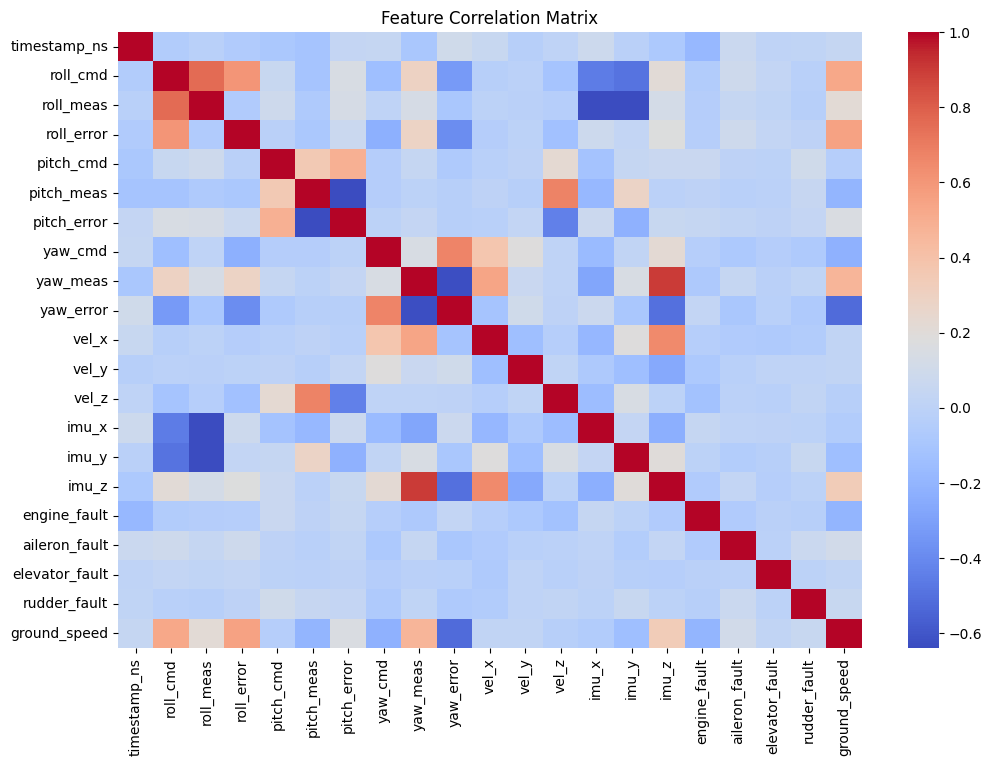

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()